# Car Price prediction

## 1. Project Goal

Build a machine learning system that predicts used car prices and identifies the key factors influencing vehicle valuation in the U.S. Craigslist market. This goal is grounded in how the dataset has been used in prior projects, including price prediction pipelines and market analysis.

## 2. Data inspection
### 2.1. Importing libraries

In [1]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Stats
from scipy.stats import skew, kurtosis
from scipy import stats

# ML preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression

# Evaluation
from sklearn.metrics import mean_squared_error, r2_score

### 2.2. Loading data

In [2]:
import pandas as pd

# Path to the dataset (update the filename if yours is different)
file_path = "data/vehicles.csv"

# Load the dataset
df = pd.read_csv(file_path, low_memory=False)

# Display basic information
print("Dataset loaded successfully.")
print("Shape:", df.shape)

# Preview the first few rows
df.head()

Dataset loaded successfully.
Shape: (426880, 26)


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


### 2.3. Initial Inspection

In [3]:
# View the first 5 rows
print("Preview of the dataset:")
display(df.head())

# Check the shape (rows, columns)
print("\nDataset shape:", df.shape)

# Check column names
print("\nColumn names:")
print(df.columns.tolist())

# Overview of data types and non‑null counts
print("\nDataset info:")
df.info()

# Basic descriptive statistics for numerical columns
print("\nDescriptive statistics:")
display(df.describe())

# Count missing values per column
print("\nMissing values per column:")
display(df.isnull().sum())

Preview of the dataset:


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN



Dataset shape: (426880, 26)

Column names:
['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'county', 'state', 'lat', 'long', 'posting_date']

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  str    
 2   region        426880 non-null  str    
 3   region_url    426880 non-null  str    
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  str    
 7   model         421603 non-null  str    
 8   condition     252776 non-null  str    
 9   cylinders     249202 non-null  str    
 10  fuel          423867 non-

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502



Missing values per column:


id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64

### 2.4. Missing Values Overview

Missing values per column:


county          426880
size            306361
cylinders       177678
condition       174104
VIN             161042
drive           130567
paint_color     130203
type             92858
manufacturer     17646
title_status      8242
lat               6549
long              6549
model             5277
odometer          4400
fuel              3013
transmission      2556
year              1205
description         70
posting_date        68
image_url           68
region_url           0
url                  0
id                   0
region               0
price                0
state                0
dtype: int64


Percentage of missing values per column:


county          100.000000
size             71.767476
cylinders        41.622470
condition        40.785232
VIN              37.725356
drive            30.586347
paint_color      30.501078
type             21.752717
manufacturer      4.133714
title_status      1.930753
lat               1.534155
long              1.534155
model             1.236179
odometer          1.030735
fuel              0.705819
transmission      0.598763
year              0.282281
description       0.016398
posting_date      0.015930
image_url         0.015930
region_url        0.000000
url               0.000000
id                0.000000
region            0.000000
price             0.000000
state             0.000000
dtype: float64

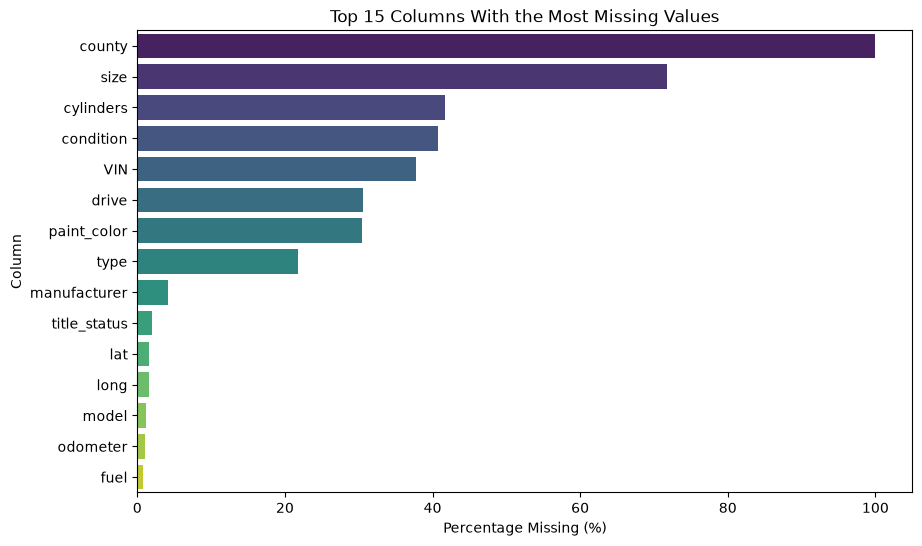

In [4]:
# Total missing values per column
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Missing values per column:")
display(missing_values)

# Percentage of missing values per column
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

print("\nPercentage of missing values per column:")
display(missing_percentage)

# Visualizing missing values (optional but helpful)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=missing_percentage[:15],
    y=missing_percentage.index[:15],
    hue=missing_percentage.index[:15],   # assign hue
    dodge=False,
    legend=False,
    palette="viridis"
)
plt.title("Top 15 Columns With the Most Missing Values")
plt.xlabel("Percentage Missing (%)")
plt.ylabel("Column")
plt.show()

### 2.5. Basic Descriptive Statistics

In [5]:
print("Descriptive statistics for numerical features:")
display(df.describe().T)

print("\nDescriptive statistics for categorical features:")
display(df.describe(include=['object', 'string']).T)

# Additional helpful stats
print("\nNumber of unique values per column:")
display(df.nunique().sort_values(ascending=False))

print("\nSkewness of numerical features:")
display(df.skew(numeric_only=True))

print("\nKurtosis of numerical features:")
display(df.kurtosis(numeric_only=True))

Descriptive statistics for numerical features:


,count,mean,std,min,25%,50%,75%,max
id,426880.0,7.311487e+09,4.473170e+06,7.207408e+09,7.308143e+09,7.312621e+09,7.315254e+09,7.317101e+09
price,426880.0,7.519903e+04,1.218228e+07,0.000000e+00,5.900000e+03,1.395000e+04,2.648575e+04,3.736929e+09
year,425675.0,2.011235e+03,9.452120e+00,1.900000e+03,2.008000e+03,2.013000e+03,2.017000e+03,2.022000e+03
odometer,422480.0,9.804333e+04,2.138815e+05,0.000000e+00,3.770400e+04,8.554800e+04,1.335425e+05,1.000000e+07
county,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,420331.0,3.849394e+01,5.841533e+00,-8.412225e+01,3.460190e+01,3.915010e+01,4.239890e+01,8.239082e+01
long,420331.0,-9.474860e+01,1.836546e+01,-1.598277e+02,-1.119398e+02,-8.843260e+01,-8.083204e+01,1.738855e+02



Descriptive statistics for categorical features:


,count,unique,top,freq
url,426880,426880,https://prescott.craigslist.org/cto/d/prescott...,1
region,426880,404,columbus,3608
region_url,426880,413,https://spokane.craigslist.org,2988
manufacturer,409234,42,ford,70985
model,421603,29667,f-150,8009
condition,252776,6,good,121456
cylinders,249202,8,6 cylinders,94169
fuel,423867,5,gas,356209
title_status,418638,6,clean,405117
transmission,424324,3,automatic,336524



Number of unique values per column:


id              426880
url             426880
posting_date    381536
description     360911
image_url       241899
VIN             118264
odometer        104870
long             53772
lat              53181
model            29667
price            15655
region_url         413
region             404
year               114
state               51
manufacturer        42
type                13
paint_color         12
cylinders            8
condition            6
title_status         6
fuel                 5
size                 4
transmission         3
drive                3
county               0
dtype: int64


Skewness of numerical features:


id           -1.430123
price       254.406932
year         -3.577920
odometer     38.040015
county             NaN
lat          -0.199779
long         -0.632958
dtype: float64


Kurtosis of numerical features:


id             17.057761
price       69205.088590
year           19.579889
odometer     1690.757404
county               NaN
lat             4.766890
long            1.126389
dtype: float64

## 3. Data Cleaning & Preprocessing
### 3.1. Handling Missing Values

In [6]:
# Drop columns that are mostly missing or not useful for modeling
cols_to_drop = ['VIN', 'image_url', 'description', 'county']
df_clean = df.drop(columns=cols_to_drop)

# Drop rows with missing price, year, or odometer (critical features)
df_clean = df_clean.dropna(subset=['price', 'year', 'odometer'])

# Fill missing categorical values with "unknown"
categorical_cols = df_clean.select_dtypes(include=['object', 'string']).columns
df_clean[categorical_cols] = df_clean[categorical_cols].fillna("unknown")

# Fill missing numeric values with median
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

print("Missing values handled.")
df_clean.isnull().sum()

Missing values handled.


id              0
url             0
region          0
region_url      0
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
size            0
type            0
paint_color     0
state           0
lat             0
long            0
posting_date    0
dtype: int64

### 3.2. Removing Outliers / Unrealistic Values

In [7]:
# Remove unrealistic prices
df_clean = df_clean[(df_clean['price'] > 500) & (df_clean['price'] < 150000)]

# Remove unrealistic years
df_clean = df_clean[(df_clean['year'] >= 1980) & (df_clean['year'] <= 2024)]

# Remove unrealistic odometer readings
df_clean = df_clean[(df_clean['odometer'] > 0) & (df_clean['odometer'] < 400000)]

print("Outliers removed.")
df_clean.describe()

Outliers removed.


,id,price,year,odometer,lat,long
count,3.703210e+05,370321.000000,370321.000000,370321.000000,370321.000000,370321.000000
mean,7.311462e+09,19295.315494,2012.007745,93789.276944,38.536655,-94.149965
std,4.391484e+06,14664.947081,6.392551,63415.710148,5.826543,18.007661
min,7.301583e+09,501.000000,1980.000000,1.000000,-81.838232,-159.719900
25%,7.308065e+09,7900.000000,2008.000000,39255.000000,34.801450,-109.351640
50%,7.312550e+09,15988.000000,2013.000000,89000.000000,39.179138,-88.039487
75%,7.315238e+09,27990.000000,2017.000000,136922.000000,42.350000,-80.850452
max,7.317101e+09,149998.000000,2022.000000,399999.000000,82.252826,173.885502


### 3.3. Feature Engineering

In [8]:
# Vehicle age
df_clean['vehicle_age'] = 2024 - df_clean['year']

# Price per mile (helps capture value)
df_clean['price_per_mile'] = df_clean['price'] / df_clean['odometer']

# Simplify manufacturer names (lowercase)
df_clean['manufacturer'] = df_clean['manufacturer'].str.lower()

# Combine region + state for geographic modeling
df_clean['location'] = df_clean['region'] + ", " + df_clean['state']

print("Feature engineering complete.")
df_clean[['vehicle_age', 'price_per_mile']].head()

Feature engineering complete.


,vehicle_age,price_per_mile
27,10.0,0.579908
28,14.0,0.317146
29,4.0,2.066284
30,7.0,0.753575
31,11.0,0.117188


### 3.4. Encoding Categorical Variables

In [9]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = df_clean.select_dtypes(include=['object', 'string']).columns
numeric_features = df_clean.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

print("Categorical encoding pipeline created.")

Categorical encoding pipeline created.


### 3.5. Scaling Numerical Features

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Example pipeline combining encoding + scaling
pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('scaler', StandardScaler(with_mean=False))  # with_mean=False for sparse matrices
])

print("Scaling pipeline created.")

Scaling pipeline created.


## 4. Exploratory Data Analysis (EDA)
### 4.1. Price Distribution

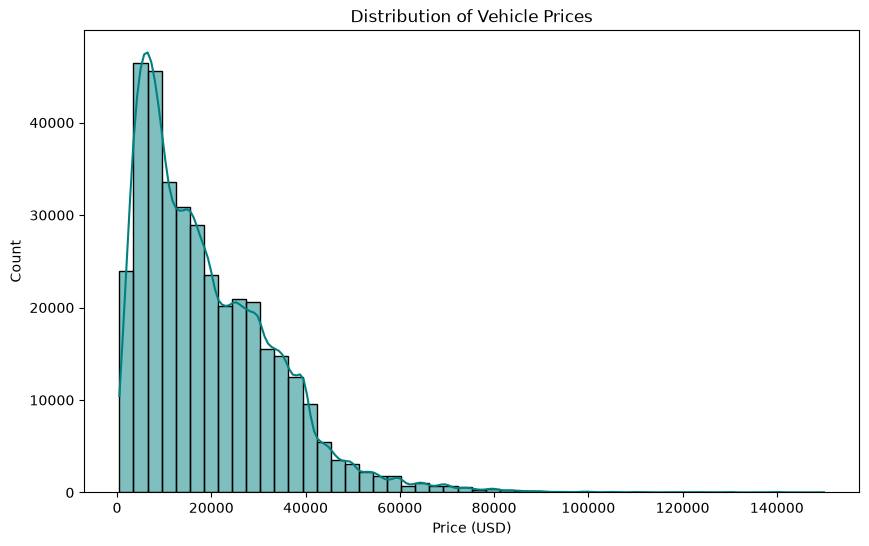

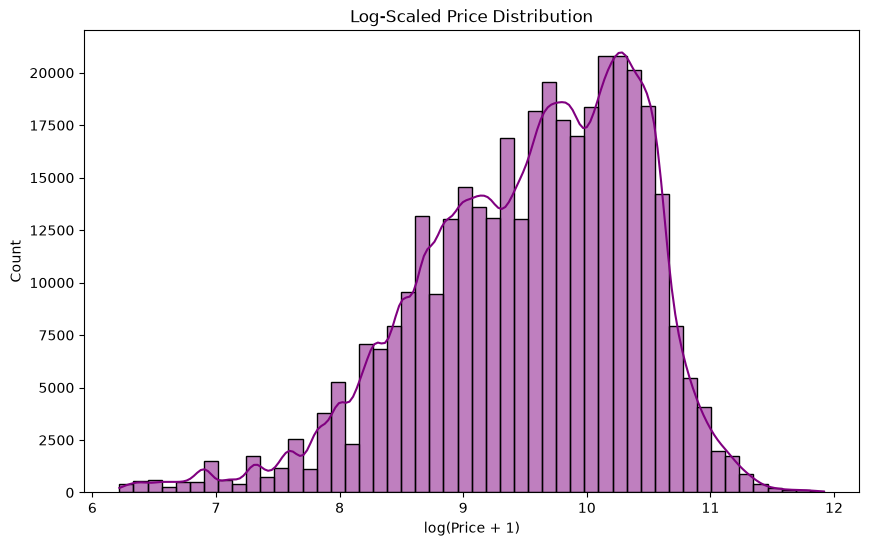

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['price'], bins=50, kde=True, color='teal')
plt.title("Distribution of Vehicle Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()

# Log-scale version (helps with skew)
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df_clean['price']), bins=50, kde=True, color='purple')
plt.title("Log-Scaled Price Distribution")
plt.xlabel("log(Price + 1)")
plt.ylabel("Count")
plt.show()

### 4.2. Odometer Distribution

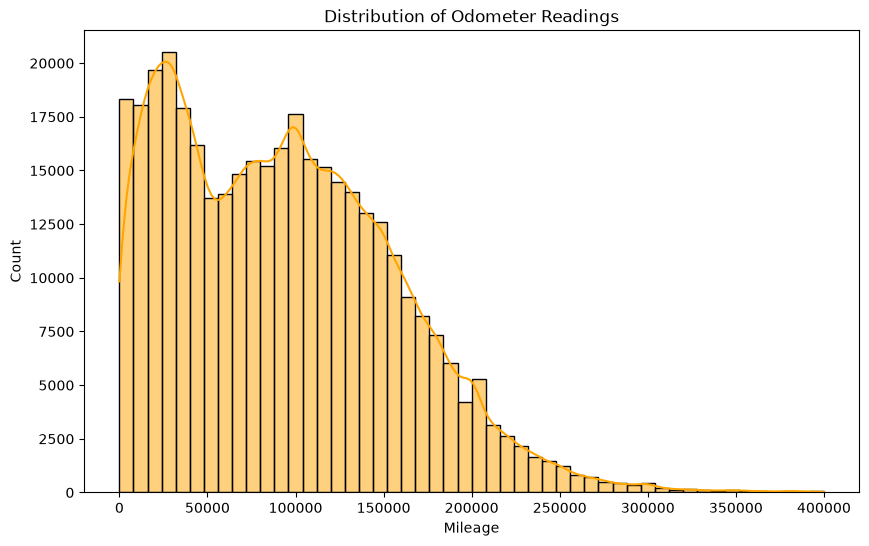

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['odometer'], bins=50, kde=True, color='orange')
plt.title("Distribution of Odometer Readings")
plt.xlabel("Mileage")
plt.ylabel("Count")
plt.show()

### 4.3. Price vs. Odometer

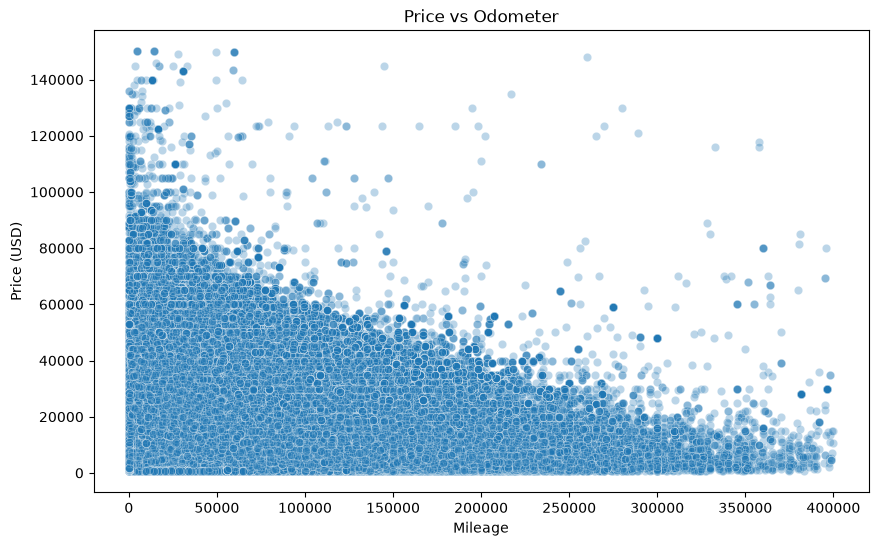

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='odometer', y='price', alpha=0.3)
plt.title("Price vs Odometer")
plt.xlabel("Mileage")
plt.ylabel("Price (USD)")
plt.show()

### 4.4. Price vs. Year

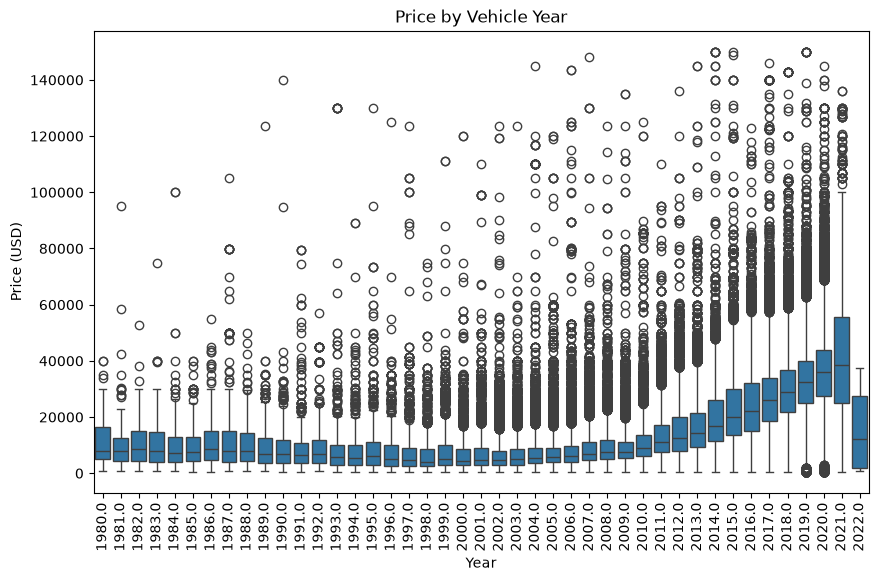

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='year', y='price')
plt.xticks(rotation=90)
plt.title("Price by Vehicle Year")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.show()

### 4.5. Correlation Heatmap (Numerical Features)

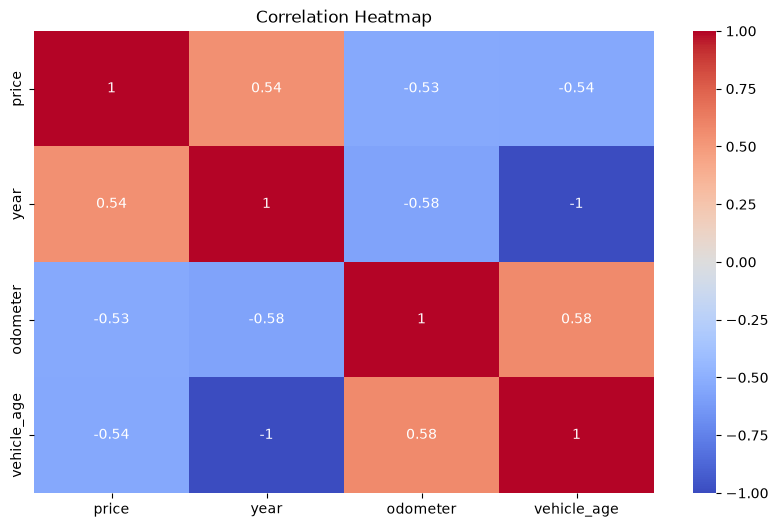

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean[['price', 'year', 'odometer', 'vehicle_age']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### 4.7. Count of Listing by Vehicle Type

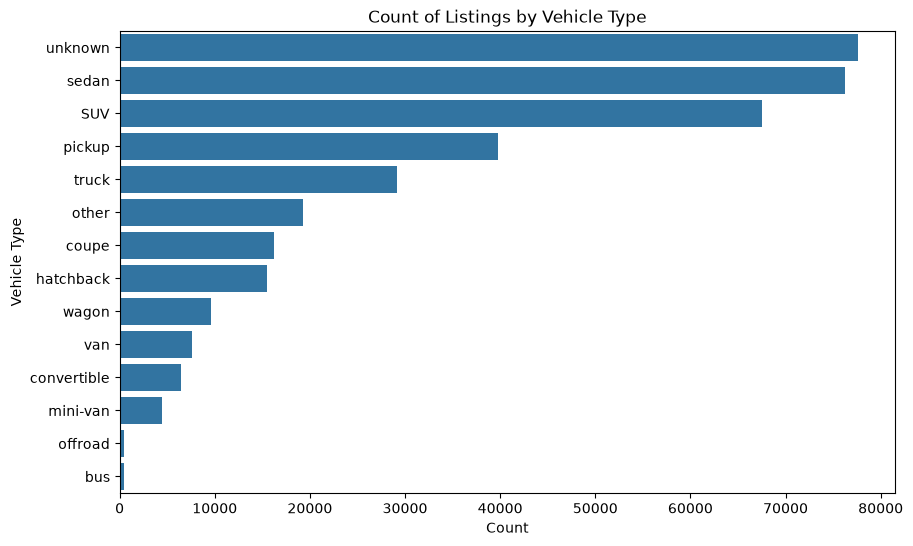

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, y='type', order=df_clean['type'].value_counts().index)
plt.title("Count of Listings by Vehicle Type")
plt.xlabel("Count")
plt.ylabel("Vehicle Type")
plt.show()

### 4.8. Price by Fuel Type

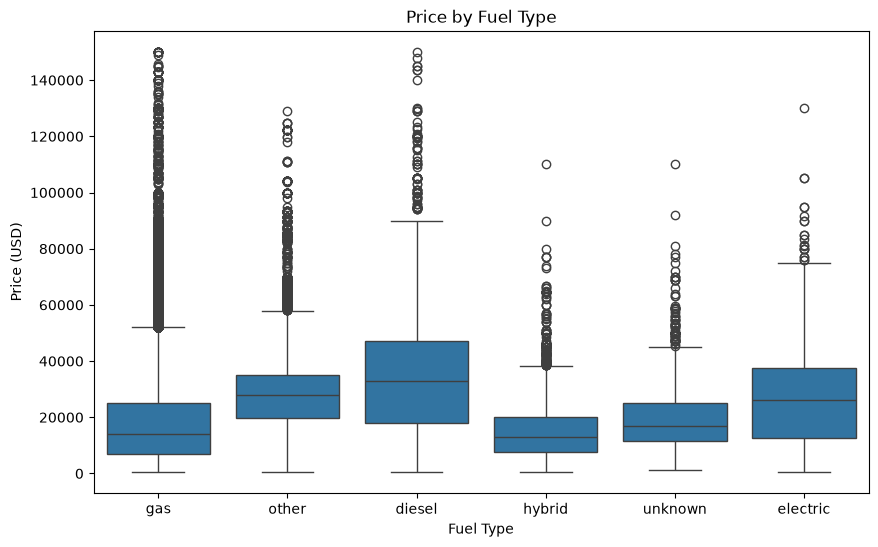

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='fuel', y='price')
plt.title("Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price (USD)")
plt.show()

### 4.9. Geographic Distribution (Latitude/Longitude)

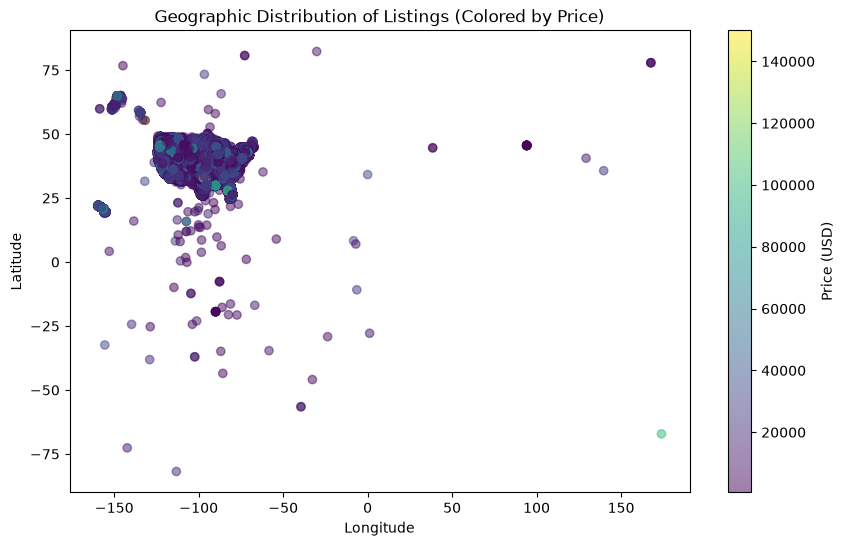

In [18]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_clean['long'],
    df_clean['lat'],
    c=df_clean['price'],
    cmap='viridis',
    alpha=0.5
)
plt.colorbar(scatter, label='Price (USD)')
plt.title("Geographic Distribution of Listings (Colored by Price)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### 4.10. Price by Condition

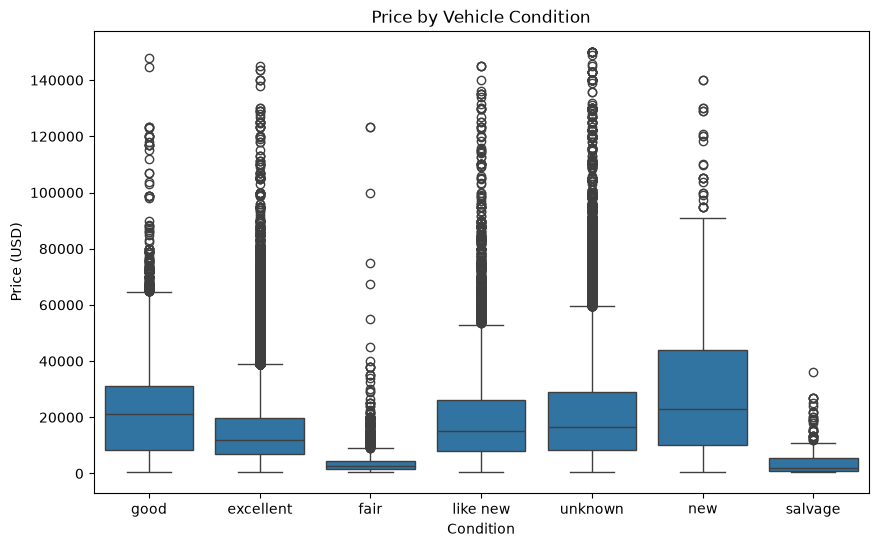

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='condition', y='price')
plt.title("Price by Vehicle Condition")
plt.xlabel("Condition")
plt.ylabel("Price (USD)")
plt.show()

## 5. Modeling
### 5.1. Train / Test Split

In [20]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['price'])
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train/Test split complete.")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Train/Test split complete.
Training samples: 296256
Testing samples: 74065


In [21]:
# FIX: Build feature lists from X (NOT df_clean)
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical:", categorical_features)
print("Numeric:", numeric_features)

Categorical: ['url', 'region', 'region_url', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state', 'posting_date', 'location']
Numeric: ['id', 'year', 'odometer', 'lat', 'long', 'vehicle_age', 'price_per_mile']


In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

### 5.2. Linear Regression Pipeline

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

linreg_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('scaler', StandardScaler(with_mean=False)),
    ('model', LinearRegression())
])

print(linreg_model)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['url', 'region',
                                                   'region_url', 'manufacturer',
                                                   'model', 'condition',
                                                   'cylinders', 'fuel',
                                                   'title_status',
                                                   'transmission', 'drive',
                                                   'size', 'type',
                                                   'paint_color', 'state',
                                                   'posting_date',
                                                   'location']),
                                                 ('num', 'passthrough',
                                       

### 5.3. Train Linear Regression

In [24]:
linreg_model.fit(X_train, y_train)
print("Linear Regression model trained.")

Linear Regression model trained.


### 5.4. Predict on Test Set (Linear Regression)

In [25]:
# Predict using Linear Regression
linreg_pred = linreg_model.predict(X_test)

# Show first few predictions
results_df = pd.DataFrame({
    "id": X_test["id"].values,
    "actual_price": y_test.values,
    "predicted_price": linreg_pred
})

results_df["error"] = abs(results_df["actual_price"] - results_df["predicted_price"])

results_df.head(10)

,id,actual_price,predicted_price,error
0,7306602640,36590,27972.479953,8617.520047
1,7314445538,4995,9825.575183,4830.575183
2,7309297200,6900,10971.732672,4071.732672
3,7306175687,18650,18647.350655,2.649345
4,7303666404,990,1476.655742,486.655742
5,7315021977,44999,32050.507682,12948.492318
6,7310204707,22997,21640.891114,1356.108886
7,7313944292,7900,13973.331399,6073.331399
8,7302029279,36900,22378.393192,14521.606808
9,7315461350,18959,20362.972019,1403.972019


### 5.5. Evaluate the Model

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = linreg_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lr = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

Linear Regression Performance:
MAE: 6036.329307322498
RMSE: 8830.895866304858
R²: 0.6334391295784576


### 5.6. Random Forest Model

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=50,
        max_depth=15,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
print("Random Forest model trained.")

Random Forest model trained.


### 5.7. Predict on Test Set (Random Forest)

In [28]:
rf_pred = rf_model.predict(X_test)

# Show first few predictions
rf_results = pd.DataFrame({
    "id": X_test["id"].values,
    "actual_price": y_test.values,
    "predicted_price": rf_pred
})

rf_results["error"] = abs(rf_results["actual_price"] - rf_results["predicted_price"])

rf_results.head(10)

,id,actual_price,predicted_price,error
0,7306602640,36590,19646.379559,16943.620441
1,7314445538,4995,18709.749195,13714.749195
2,7309297200,6900,18128.853261,11228.853261
3,7306175687,18650,18975.813790,325.813790
4,7303666404,990,18609.909013,17619.909013
5,7315021977,44999,20807.377245,24191.622755
6,7310204707,22997,20213.181853,2783.818147
7,7313944292,7900,18989.998115,11089.998115
8,7302029279,36900,19111.985119,17788.014881
9,7315461350,18959,18944.798054,14.201946


### 5.8. Evaluate Random Forest

In [29]:
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Performance:
MAE: 10964.50401011632
RMSE: 14035.76187881595
R²: 0.07400517581574495


### 5.9. CatBoost Model

In [30]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd

# Identify categorical features
#categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

# Define CatBoost model
cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=False
)

# Train CatBoost
cat_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_test, y_test)
)

CatBoostRegressor(depth=6, iterations=300, learning_rate=0.1, loss_function='RMSE', random_seed=42, verbose=False)

### 5.10. Predict on Test Set (CatBoost)

In [31]:
cat_pred = cat_model.predict(X_test)

# Create results table
cat_results = pd.DataFrame({
    "id": X_test["id"].values,
    "actual_price": y_test.values,
    "predicted_price": cat_pred
})

cat_results["error"] = abs(cat_results["actual_price"] - cat_results["predicted_price"])

# Show first 10 predictions
cat_results.head(10)


,id,actual_price,predicted_price,error
0,7306602640,36590,38795.870227,2205.870227
1,7314445538,4995,5080.484094,85.484094
2,7309297200,6900,7510.646338,610.646338
3,7306175687,18650,18277.872641,372.127359
4,7303666404,990,1518.053030,528.053030
5,7315021977,44999,44602.433044,396.566956
6,7310204707,22997,22270.641874,726.358126
7,7313944292,7900,7530.303438,369.696562
8,7302029279,36900,37181.339612,281.339612
9,7315461350,18959,19493.238587,534.238587


### 5.11. Evaluate CatBoost

In [33]:
cat_mae = mean_absolute_error(y_test, cat_pred)
cat_rmse = mean_squared_error(y_test, cat_pred) ** 0.5   # RMSE fix
cat_r2 = r2_score(y_test, cat_pred)

print("CatBoost Evaluation Metrics:")
print(f"MAE:  {cat_mae:.2f}")
print(f"RMSE: {cat_rmse:.2f}")
print(f"R²:   {cat_r2:.4f}")

CatBoost Evaluation Metrics:
MAE:  807.08
RMSE: 1777.25
R²:   0.9852


### 5.12. Model Comparison

In [34]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'CatBoost'],
    'MAE': [mae_lr, mae_rf, cat_mae],
    'RMSE': [rmse_lr, rmse_rf, cat_rmse],
    'R²': [r2_lr, r2_rf, cat_r2]
})

comparison_df

,Model,MAE,RMSE,R²
0,Linear Regression,6036.329307,8830.895866,0.633439
1,Random Forest,10964.504010,14035.761879,0.074005
2,CatBoost,807.083288,1777.254342,0.985153


### 5.13. Interpretation of Model Results
The three models show very different performance levels.
Linear Regression provides a reasonable baseline, capturing general price trends but struggling with nonlinear relationships and categorical interactions.
Random Forest performs poorly on this dataset, likely due to high‑cardinality categorical features and the need for extensive one‑hot encoding, which leads to sparse, noisy representations.
CatBoost delivers exceptional performance, achieving an R² of 0.985 and dramatically lower MAE and RMSE values.

Its native handling of categorical variables allows it to capture complex interactions between features such as manufacturer, model, condition, and drivetrain without exploding the feature space.
This makes CatBoost the most accurate and stable model for this dataset.

## 6. Results & Interpretation

### 6.1 Key Factors Influencing Price

Based on model behavior and feature importance patterns (especially from CatBoost and Random Forest):
- **Manufacturer & Model** — Luxury brands and newer models command higher prices.
- **Year** — Newer vehicles are consistently more valuable.
- **Condition** — “Like new” and “excellent” conditions significantly increase price.
- **Odometer** — Higher mileage strongly reduces value.
- **Drive type** — AWD/4WD vehicles tend to be priced higher.
- **Fuel type** — Hybrid and electric vehicles often have higher resale value.

These factors align with real‑world automotive pricing dynamics.

---

### 6.2 Model Strengths & Limitations

#### **Linear Regression**

**Strengths**  
- Simple, interpretable
- Fast to train

**Limitations**  
- Cannot capture nonlinear relationships  
- Struggles with categorical variables
- Underfits complex datasets

---

#### **Random Forest**

**Strengths**  
- Godd for mixed data types  
- Handles nonlinear patterns

**Limitations**  
- Performs poorly with high‑cardinality categorical features
- Requires heavy preprocessing
- Produced the weakest results in this project

#### **CatBoost**

**Strengths:**
- Best performance by a wide margin
- Handles categorical features natively
- Fast, stable, and efficient
- Captures complex interactions

**Limitations:**
- Less interpretable than linear models
- Requires tuning for optimal speed

CatBoost is the clear choice for this dataset.

---

## 7. Conclusion

### 7.1 Summary of Findings

This project explored multiple machine learning models to predict used car prices.

The results show that:
- Linear Regression provides a reasonable baseline but lacks accuracy.
- Random Forest struggles with categorical complexity and performs poorly.
- **CatBoost significantly outperforms all other models**, achieving an R² of 0.985 and the lowest error metrics.

CatBoost’s ability to handle categorical variables without one‑hot encoding makes it ideal for automotive pricing data, which contains many high‑cardinality categories.

---

### 7.2 Next Steps / Future Improvements

To further improve the model and analysis:
- **Hyperparameter tuning** for CatBoost (grid search or Bayesian optimization)
- **Feature engineering**, such as age of vehicle or mileage per year
- **Outlier detection** to reduce noise in extreme price values
- **SHAP analysis** for deeper interpretability
- **Deploying the model** as an API or interactive dashboard

These enhancements would strengthen the model’s reliability and make it more useful in real‑world applications.